# Neural Network

In [1]:
import numpy as np

In [3]:
def sigmoid(x):
    return 1 / (1+ np.exp(-x))

In [4]:
class Neuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias
    
    def feedforward(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return sigmoid(total)

In [5]:
weights = np.array((0, 1))

In [6]:
weights

array([0, 1])

In [7]:
bias = 4

In [8]:
n = Neuron(weights, bias)

In [9]:
x = np.array([2, 3])

In [11]:
print(n.feedforward(x))

0.9990889488055994


In [12]:
import numpy as np

class OurNeuralNetwork:
    '''
    Neural network with two hidden neurons and one output, each neuron has same weight and bias
    '''
    def __init__(self):
        weights = np.array([0,1])
        bias = 0
        
        self.h1 = Neuron(weights, bias)
        self.h2 = Neuron(weights, bias)
        self.o1 = Neuron(weights, bias)
        
    def feedforward(self, x):
        out_h1 = self.h1.feedforward(x)
        out_h2 = self.h2.feedforward(x)
        
        out_o1 = self.o1.feedforward(np.array([out_h1, out_h2]))
        return out_o1


In [13]:
network = OurNeuralNetwork()
x = np.array([2,3])
print(network.feedforward(x))

0.7216325609518421


### Training a neural network

In [17]:
import numpy as np

def mse_loss(y_true, y_pred):
    return ((y_true - y_pred)** 2).mean()

y_true = np.array([1, 0, 0, 1])
y_pred = np.array([0, 0, 0, 0])

print(mse_loss(y_true, y_pred))

0.5


In [218]:
np.random.normal()

2.540123228143074

In [126]:
import numpy as np
from tqdm import tqdm

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    # Derivative of sigmoid: f'(x) = f(x) * (1 - f(x))
    fx = sigmoid(x)
    return fx * (1 - fx)

def mse_loss(y_true, y_pred):
    return ((y_true - y_pred)**2).mean()

class OurNeuralNetwork:
    def __init__(self):
        # weights for 2 *2 * 1 Neural network (2 input, hidden,1 output)
        self.w1 = np.random.normal()
        self.w2= np.random.normal()
        self.w3= np.random.normal()
        self.w4= np.random.normal()
        self.w5= np.random.normal()
        self.w6= np.random.normal()
        
        # biases for each hidden neuron and output
        self.b1 = np.random.normal()
        self.b2 = np.random.normal()
        self.b3= np.random.normal()
        
        self.losses = []
        
    def feed_forward(self, x):
        h1 = sigmoid(self.w1 * x[0] + self.w2 * x[1] + self.b1)
        h2 = sigmoid(self.w3 * x[0] + self.w4 * x[1] + self.b2)
        o1 = sigmoid(self.w5 * h1 + self.w6 * h2 + self.b3)
        return o1

    def train(self, data, all_y_trues):
        '''
        - data is a (n x 2) numpy array, n = # of samples in the dataset.
        - all_y_trues is a numpy array with n elements.
          Elements in all_y_trues correspond to those in data.
        '''
        learn_rate = 0.01
        epochs = 1000 # number of times to loop through entire dataset

        for epochs in tqdm(range(epochs)):
            for x, y_true in zip(data, all_y_trues):
                # step 1. Do a feed-forward
                sum_h1 = self.w1 * x[0] + self.w2 * x[1] + self.b1
                h1 = sigmoid(sum_h1)

                sum_h2 = self.w3 * x[0] + self.w4 * x[1] + self.b2
                h2 = sigmoid(sum_h2)

                sum_o1 = self.w5 * h1 + self.w6 * h2 + self.b3
                o1 = sigmoid(sum_o1)

                y_pred = o1


                # Backk prop -- dcalculate partial derivatives
                # --- Calculate partial derivatives.
                # --- Naming: d_L_d_w1 represents "partial L / partial w1"

                d_L_d_ypred = -2 * (y_true - y_pred)

                # Neuron o1
                d_ypred_d_w5 = h1 * deriv_sigmoid(sum_o1)
                d_ypred_d_w6 = h2 * deriv_sigmoid(sum_o1)
                d_ypred_d_b3 = deriv_sigmoid(sum_o1)

                d_ypred_d_h1 = self.w5 * deriv_sigmoid(sum_o1)
                d_ypred_d_h2 = self.w6 * deriv_sigmoid(sum_o1)

                # Neuron h1
                d_h1_d_w1 = x[0] * deriv_sigmoid(sum_h1)
                d_h1_d_w2 = x[1] * deriv_sigmoid(sum_h1)
                d_h1_d_b1 = deriv_sigmoid(sum_h1)

                # Neuron h2
                d_h2_d_w3 = x[0] * deriv_sigmoid(sum_h2)
                d_h2_d_w4 = x[1] * deriv_sigmoid(sum_h2)
                d_h2_d_b2 = deriv_sigmoid(sum_h2)

                # Update weight and biases -- Gradient Descent

                # Neuron h1
                self.w1 = self.w1 - learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w1
                self.w2 = self.w2 - learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w2
                self.b1 = self.b1 - learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_b1

                # Neuron h2
                self.w3 = self.w3 - learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w3
                self.w4 = self.w4 - learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w4
                self.b2 = self.b2 - learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_b2

                # Neuron o1
                self.w5 = self.w5 - learn_rate * d_L_d_ypred * d_ypred_d_w5
                self.w6 = self.w6 - learn_rate * d_L_d_ypred * d_ypred_d_w6
                self.b3 = self.b3 - learn_rate * d_L_d_ypred * d_ypred_d_b3


                if epochs% 10 == 0:
                    y_preds = np.apply_along_axis(self.feed_forward, 1, data)
                    loss = mse_loss(all_y_trues, y_preds)
                    # print("Epoch %d loss: %.3f" % (epochs,loss))
                    self.losses.append(loss)
                    

In [127]:
data = np.array([
  [-2, -1],  # Alice
  [25, 6],   # Bob
  [17, 4],   # Charlie
  [-15, -6], # Diana
])
all_y_trues = np.array([
  1, # Alice
  0, # Bob
  0, # Charlie
  1, # Diana
])

In [128]:
network = OurNeuralNetwork()

network.train(data, all_y_trues)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 7461.28it/s]


In [129]:
network.b1

-1.2653559106067482

In [130]:
network.w1

0.4612156197135896

In [131]:
network.w2

1.1262815117691063

In [132]:
network.w3

-1.3400678826936296

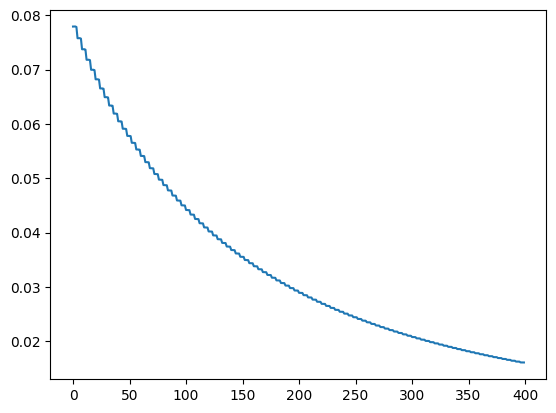

In [133]:
import matplotlib.pyplot as plt

plt.plot(list(range(len(network.losses))), network.losses)